# Importing Library

In [36]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom , RandomTranslation , RandomContrast , RandomBrightness
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.regularizers import l2

# Importing Dataset

In [37]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 123
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 6799 files belonging to 3 classes.
Using 5440 files for training.
Found 6799 files belonging to 3 classes.
Using 1359 files for validation.
Found 2278 files belonging to 3 classes.


# Data Preprocessing

In [38]:
data_augmentation = tf.keras.Sequential([
    RandomRotation(factor=(-0.025, 0.025)),
    RandomTranslation(height_factor=0.05, width_factor=0.05),
    RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05)),
    RandomContrast(factor=0.1),
    RandomFlip(mode="horizontal"),
    RandomBrightness(factor=0.1)
], name="data_augmentation")

def cutmix_sparse(batch_x, batch_y, alpha=1.0):
    batch_size = tf.shape(batch_x)[0]

    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_x = tf.gather(batch_x, indices)
    shuffled_y = tf.gather(batch_y, indices)

    lam = tf.random.uniform([], 0, 1)

    H, W = IMG_SIZE
    r_x = tf.cast(W * tf.random.uniform([], 0, 1), tf.int32)
    r_y = tf.cast(H * tf.random.uniform([], 0, 1), tf.int32)
    r_w = tf.cast(W * tf.math.sqrt(1 - lam), tf.int32)
    r_h = tf.cast(H * tf.math.sqrt(1 - lam), tf.int32)

    x1 = tf.clip_by_value(r_x - r_w // 2, 0, W)
    y1 = tf.clip_by_value(r_y - r_h // 2, 0, H)
    x2 = tf.clip_by_value(r_x + r_w // 2, 0, W)
    y2 = tf.clip_by_value(r_y + r_h // 2, 0, H)

    mask = tf.ones([y2 - y1, x2 - x1, 3])
    pad_top = y1
    pad_left = x1
    pad_bottom = H - y2
    pad_right = W - x2
    mask = tf.pad(mask, [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]])
    mask = 1 - mask

    mixed_x = batch_x * mask + shuffled_x * (1 - mask)

    mixed_y = tf.where(lam > 0.5, batch_y, shuffled_y)

    return mixed_x, mixed_y


train_ds_augmented = train_ds.map(
    lambda x, y: cutmix_sparse(x, y), num_parallel_calls=AUTOTUNE
)


# Model Creation

In [39]:
def build_model(input_shape=IMG_SIZE+(3,), num_classes=3):
    base_model = ResNet50(
        include_top=False,
        input_shape=input_shape,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = data_augmentation(inputs)      
    x = base_model(x, training=False)    
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation="softmax", kernel_regularizer=l2(1e-4))(x)
    model = Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=1e-3,
        first_decay_steps=1000,
        t_mul=2.0,
        m_mul=0.8,
        alpha=1e-6
    )
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=[SparseCategoricalAccuracy(name="accuracy")]
    )
    return model, base_model

model, base_model = build_model()
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Training The Model

In [40]:
history1 = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    ]
)

Epoch 1/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 31s 76ms/step - accuracy: 0.5206 - loss: 1.0249 - val_accuracy: 0.6372 - val_loss: 0.7890
Epoch 2/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.5783 - loss: 0.9203 - val_accuracy: 0.6556 - val_loss: 0.7623
Epoch 3/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.5914 - loss: 0.9022 - val_accuracy: 0.6843 - val_loss: 0.7478
Epoch 4/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.5822 - loss: 0.9237 - val_accuracy: 0.6711 - val_loss: 0.7789
Epoch 5/5
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 68ms/step - accuracy: 0.5879 - loss: 0.9070 - val_accuracy: 0.7130 - val_loss: 0.6940


# Fine Tuning

## Total Layers of The Base Model

In [41]:
print("Base model has", len(base_model.layers), "layers.")

Base model has 175 layers.


## Tuning Process

In [42]:
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True


model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5), 
    loss="sparse_categorical_crossentropy",
    metrics=[SparseCategoricalAccuracy(name="accuracy")]
)

history2 = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=20,
    callbacks=[
        ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss"),
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)
    ]
)

Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 58s 136ms/step - accuracy: 0.5974 - loss: 0.9075 - val_accuracy: 0.7196 - val_loss: 0.6659 - learning_rate: 1.0000e-04
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 44s 128ms/step - accuracy: 0.6631 - loss: 0.7859 - val_accuracy: 0.7947 - val_loss: 0.5365 - learning_rate: 1.0000e-04
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 127ms/step - accuracy: 0.6952 - loss: 0.7271 - val_accuracy: 0.8043 - val_loss: 0.4777 - learning_rate: 1.0000e-04
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 45s 132ms/step - accuracy: 0.7028 - loss: 0.7107 - val_accuracy: 0.8278 - val_loss: 0.4472 - learning_rate: 1.0000e-04
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 43s 127ms/step - accuracy: 0.7107 - loss: 0.6929 - val_accuracy: 0.8278 - val_loss: 0.4134 - learning_rate: 1.0000e-04
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 44s 130ms/step - accuracy: 0.7335 - loss: 0.6599 - val_accuracy: 0.8396 - val_loss: 0.4006 - learning_rate: 1.0000e-04
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 44s 12

# Evaluate

In [43]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

143/143 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.8872 - loss: 0.3227
Test Accuracy: 0.8871817588806152


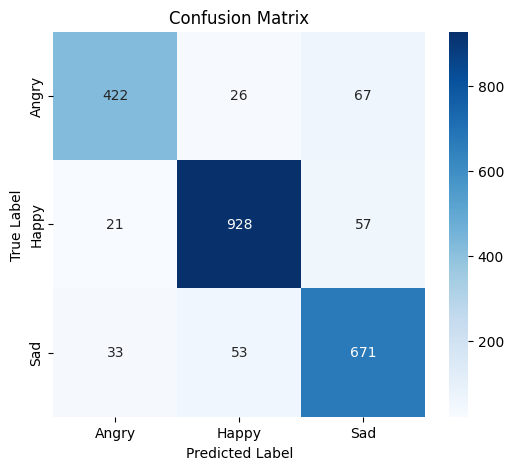

Classification Report:

              precision    recall  f1-score   support

       Angry     0.8866    0.8194    0.8517       515
       Happy     0.9215    0.9225    0.9220      1006
         Sad     0.8440    0.8864    0.8647       757

    accuracy                         0.8872      2278
   macro avg     0.8840    0.8761    0.8795      2278
weighted avg     0.8879    0.8872    0.8871      2278



In [44]:
y_true = np.concatenate([y for _, y in test_ds], axis=0)
preds = model.predict(test_ds, verbose=0)
y_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


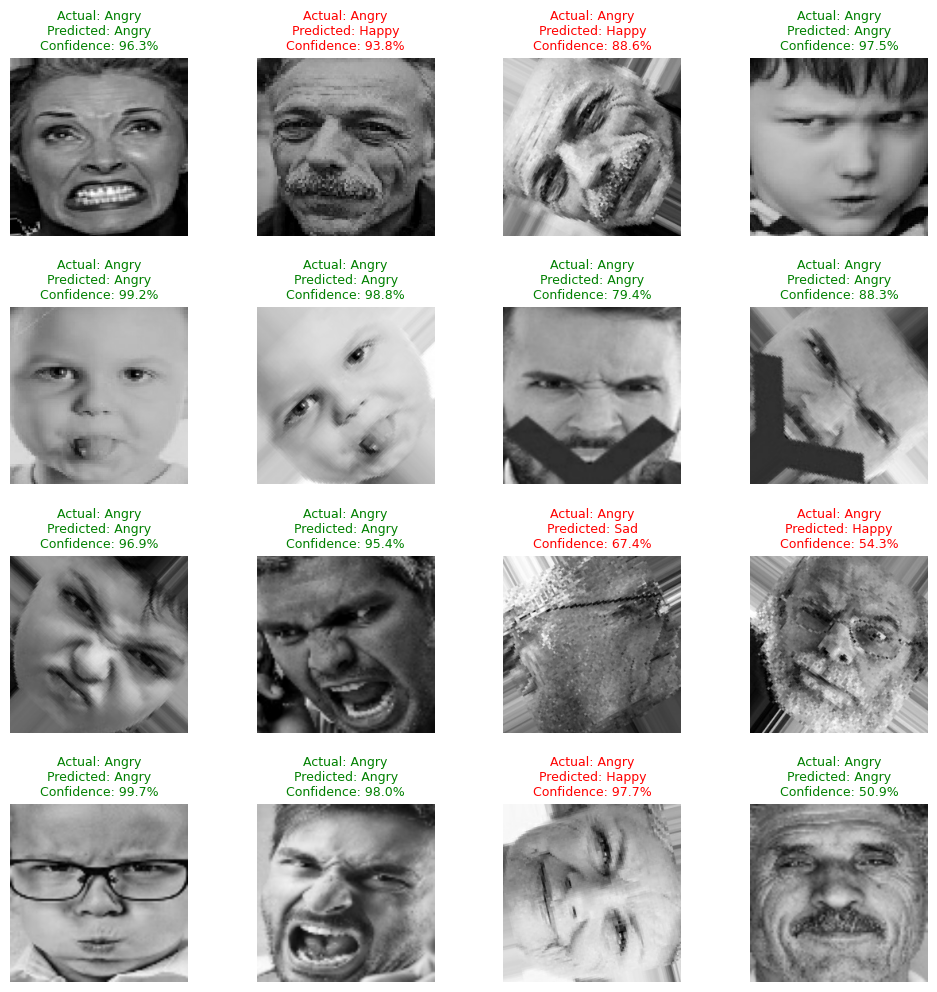

In [49]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted_full_multiclass(model, dataset, class_names, num_samples=16):
    rows = cols = int(np.sqrt(num_samples))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
    axes = axes.flatten()
    for images, labels in dataset.take(1):  
        preds = model.predict(images)
        pred_labels = np.argmax(preds, axis=1)
        labels = labels.numpy()
        for i in range(min(num_samples, len(images))):
            img = images[i].numpy().astype("uint8")
            axes[i].imshow(img)
            
            true_label = class_names[labels[i]]
            predicted_label = class_names[pred_labels[i]]
            confidence = preds[i][pred_labels[i]]
            color = 'green' if labels[i] == pred_labels[i] else 'red'
            axes[i].set_title(f"Actual: {true_label}\nPredicted: {predicted_label}\nConfidence: {confidence*100:.1f}%",
                              fontsize=9, color=color)
            axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.subplots_adjust(wspace=0.3, hspace=0.4)
    plt.show()
class_names = ['Angry', 'Happy', 'Sad']
plot_actual_vs_predicted_full_multiclass(model, test_ds, class_names, num_samples=16)
